## 1. Import Libraries

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for preprocessing, model building and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset

In [ ]:
# Load the loan prediction dataset
# Dataset source: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
df = pd.read_csv('ml-assignment/loan-dataset.csv')

# Display the first few rows to understand the structure
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
df.head()

Dataset Shape: (614, 13)
Number of rows: 614, Number of columns: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Overview of data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [5]:
# Statistical summary of numerical columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 3. Exploratory Data Analysis (EDA)

Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


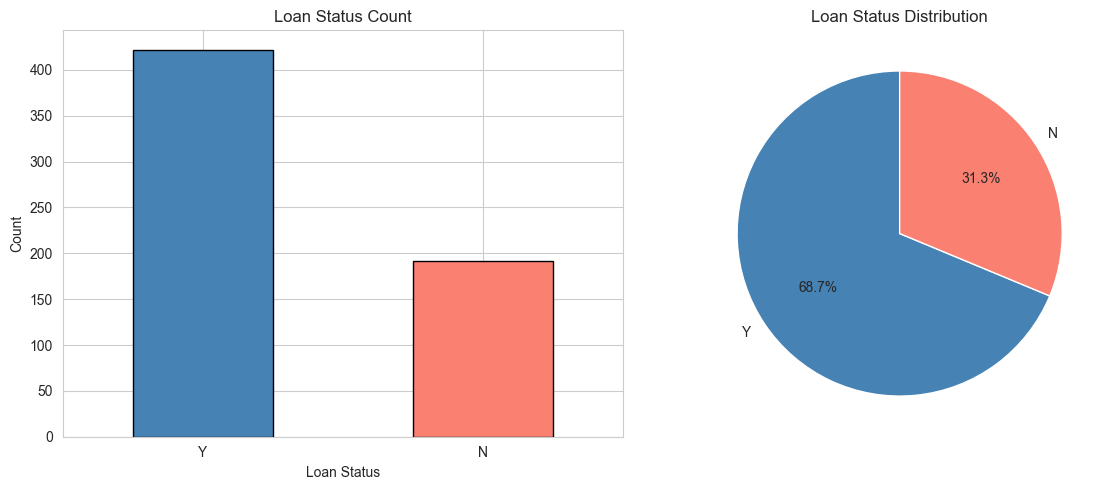

In [6]:
# Check class distribution of the target variable
print("Loan Status Distribution:")
print(df['Loan_Status'].value_counts())

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Loan Status Count')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Loan_Status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                       colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Loan Status Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [7]:
# Check for missing values in each column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values Per Column:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Per Column:
                  Missing Count  Missing %
Gender                       13   2.117264
Married                       3   0.488599
Dependents                   15   2.442997
Self_Employed                32   5.211726
LoanAmount                   22   3.583062
Loan_Amount_Term             14   2.280130
Credit_History               50   8.143322


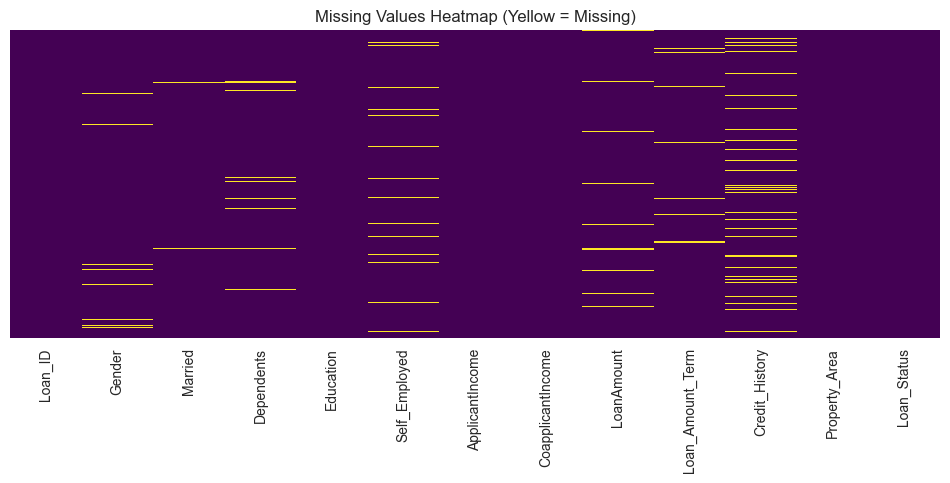

In [8]:
# Visualize missing values as a heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.show()

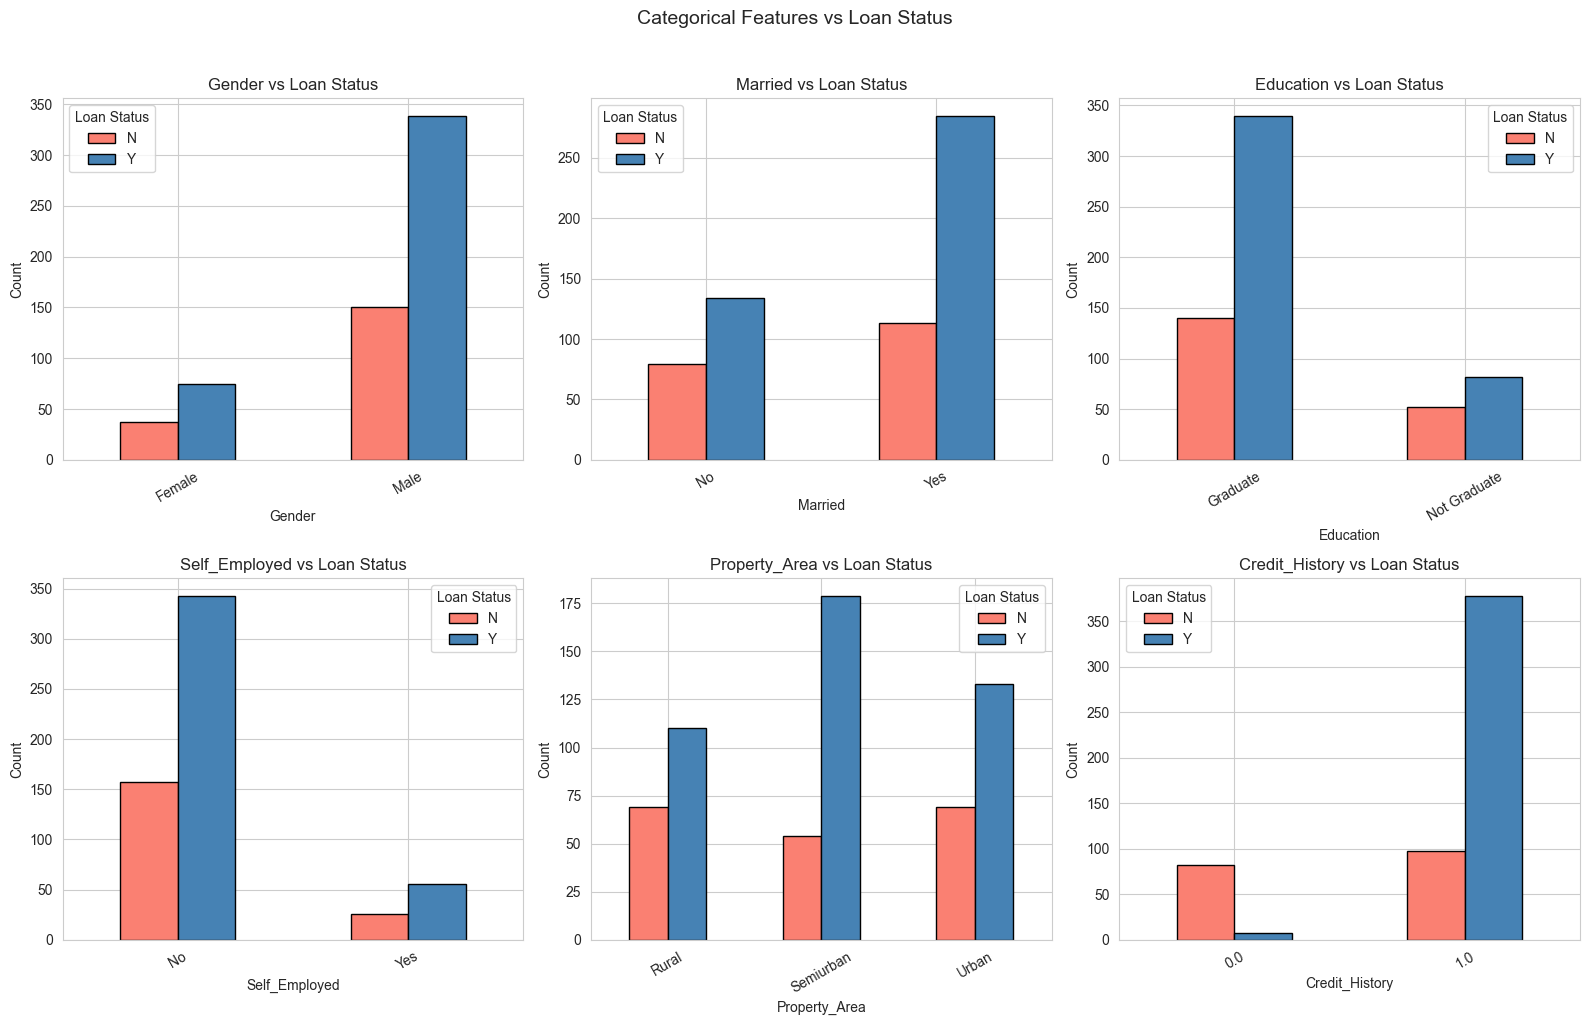

In [9]:
# Explore relationships between key categorical features and Loan Status
cat_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['Loan_Status'])
    ct.plot(kind='bar', ax=axes[i], color=['salmon', 'steelblue'], edgecolor='black')
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Loan Status')

plt.suptitle('Categorical Features vs Loan Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

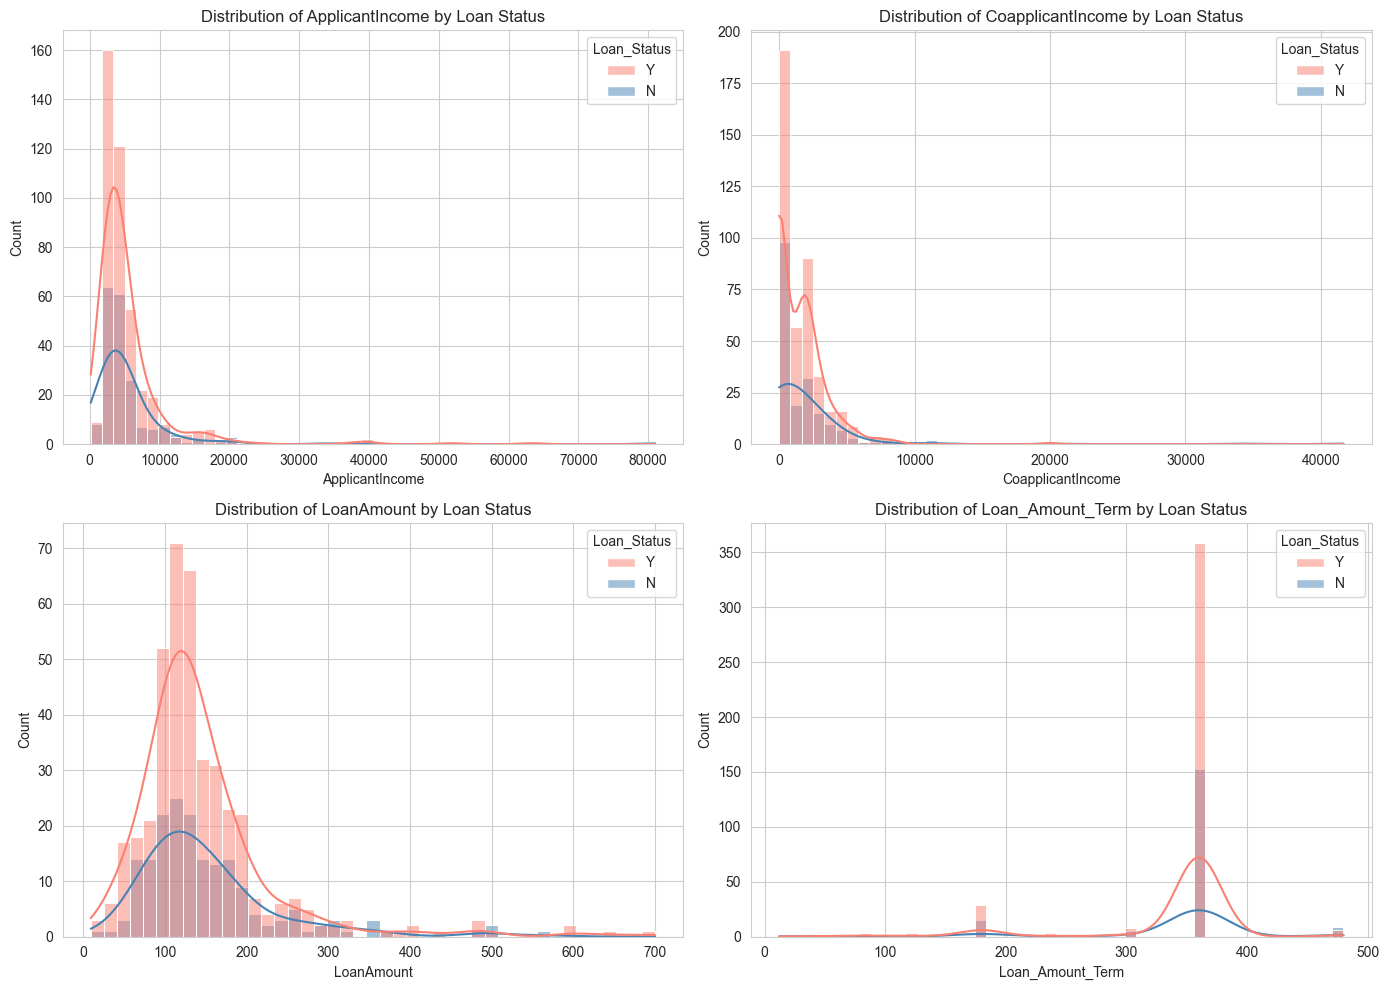

In [10]:
# Distribution of numerical features
num_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue='Loan_Status', kde=True, ax=axes[i],
                 palette=['salmon', 'steelblue'])
    axes[i].set_title(f'Distribution of {col} by Loan Status')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
# Drop Loan_ID as it is just an identifier and has no predictive value
df.drop('Loan_ID', axis=1, inplace=True)
print("Dropped Loan_ID column.")
print(f"Remaining columns: {list(df.columns)}")

Dropped Loan_ID column.
Remaining columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [13]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']

for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled '{col}' missing values with mode: {mode_val}")

for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled '{col}' missing values with median: {median_val}")

print(f"Missing values after imputation: {df.isnull().sum().sum()}")


Filled 'Gender' missing values with mode: Male
Filled 'Married' missing values with mode: Yes
Filled 'Dependents' missing values with mode: 0
Filled 'Self_Employed' missing values with mode: No
Filled 'Credit_History' missing values with mode: 1.0
Filled 'LoanAmount' missing values with median: 128.0
Filled 'Loan_Amount_Term' missing values with median: 360.0
Missing values after imputation: 0


In [14]:
# Feature Engineering: Create a Total Income feature by combining applicant and co-applicant income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Log-transform skewed numerical features to reduce the effect of outliers
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])
df['Total_Income_log'] = np.log1p(df['Total_Income'])

# Drop the original skewed columns now that we have log-transformed versions
df.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income'], axis=1, inplace=True)

print("Feature engineering complete.")
print(f"Updated columns: {list(df.columns)}")

Feature engineering complete.
Updated columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'LoanAmount_log', 'Total_Income_log']


In [15]:
# Encode all categorical/object columns using Label Encoding
# Label Encoding converts text labels to numbers (e.g., Y=1, N=0)
le = LabelEncoder()

object_cols = df.select_dtypes(include='str').columns
print(f"Columns to encode: {list(object_cols)}")

for col in object_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded '{col}'")

print("\nDataset after encoding:")
df.head()

Columns to encode: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Encoded 'Gender'
Encoded 'Married'
Encoded 'Dependents'
Encoded 'Education'
Encoded 'Self_Employed'
Encoded 'Property_Area'
Encoded 'Loan_Status'

Dataset after encoding:


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,Total_Income_log
0,1,0,0,0,0,360.0,1.0,2,1,4.859812,8.674197
1,1,1,1,0,0,360.0,1.0,0,0,4.859812,8.714732
2,1,1,0,0,1,360.0,1.0,2,1,4.204693,8.006701
3,1,1,0,1,0,360.0,1.0,2,1,4.795791,8.505525
4,1,0,0,0,0,360.0,1.0,2,1,4.955827,8.699681


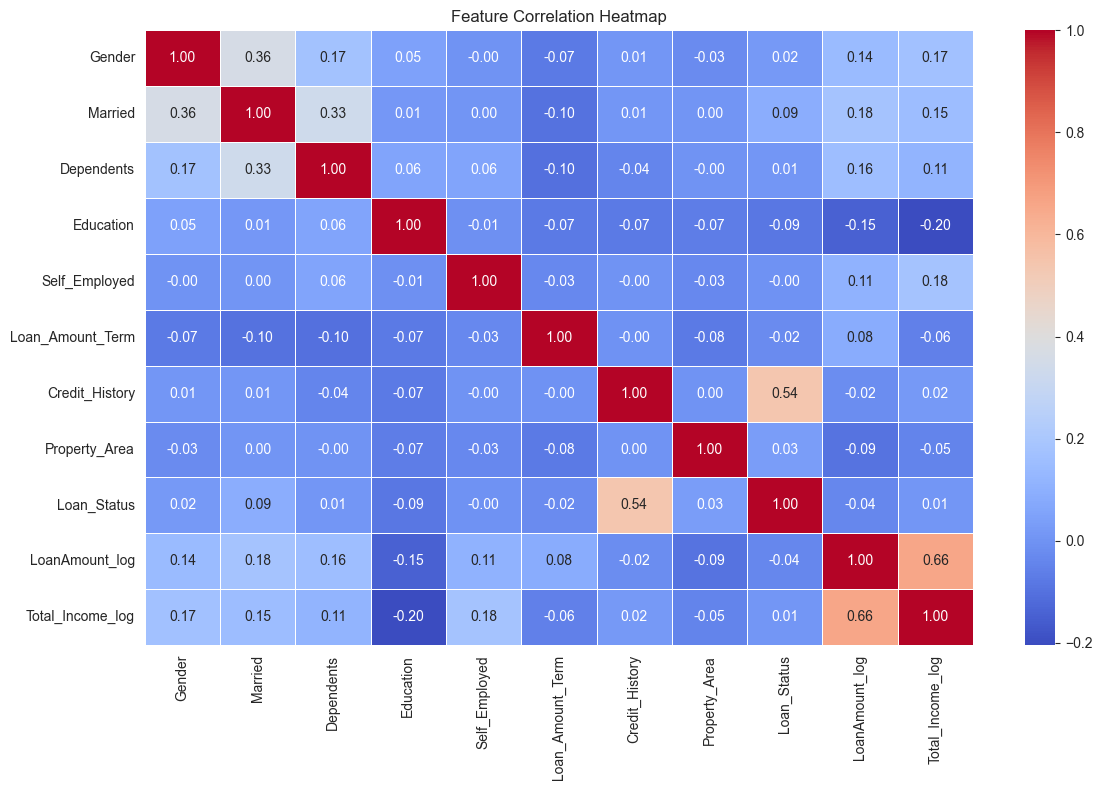

In [16]:
# Correlation heatmap to understand feature relationships
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [17]:
# Split dataset into features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")

Feature matrix shape: (614, 10)
Target vector shape: (614,)

Features used: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'LoanAmount_log', 'Total_Income_log']


In [18]:
# Split into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())
print(f"\nClass distribution in test set:")
print(pd.Series(y_test).value_counts())

Training set size: 491 samples
Testing set size:  123 samples

Class distribution in training set:
Loan_Status
1    337
0    154
Name: count, dtype: int64

Class distribution in test set:
Loan_Status
1    85
0    38
Name: count, dtype: int64


## 5. Model Training

In [19]:
# --- Baseline Random Forest Model ---
# Start with default hyperparameters as a benchmark
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# Predictions on test set
y_pred_baseline = rf_baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Random Forest Accuracy: {baseline_acc * 100:.2f}%")

Baseline Random Forest Accuracy: 82.11%


In [20]:
# --- Hyperparameter Tuning using GridSearchCV ---
# GridSearchCV exhaustively searches over specified parameter values
# cv=5 means 5-fold cross-validation is used to evaluate each combination

param_grid = {
    'n_estimators': [50, 100, 200],          # Number of trees in the forest
    'max_depth': [None, 5, 10, 15],          # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],         # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]            # Minimum samples at a leaf node
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # Use all available CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters found: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best Cross-Validation Accuracy: 79.84%


In [21]:
# --- Tuned Random Forest Model ---
# Use the best parameters identified by GridSearchCV
best_params = grid_search.best_params_

rf_tuned = RandomForestClassifier(**best_params, random_state=42)
rf_tuned.fit(X_train, y_train)

print("Tuned Random Forest model trained successfully.")
print(f"Model parameters: {rf_tuned.get_params()}")

Tuned Random Forest model trained successfully.
Model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## 7. Model Evaluation

In [22]:
# Predictions from tuned model
y_pred = rf_tuned.predict(X_test)
y_pred_proba = rf_tuned.predict_proba(X_test)[:, 1]  # Probability scores for ROC curve

# --- Accuracy Score ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Baseline Accuracy: {baseline_acc * 100:.2f}%")
print(f"Improvement: {(accuracy - baseline_acc) * 100:.2f}%")

Test Accuracy: 84.55%
Baseline Accuracy: 82.11%
Improvement: 2.44%


In [23]:
# --- Classification Report ---
# Shows Precision, Recall, and F1-Score for each class
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Approved (N)', 'Approved (Y)']))

Classification Report:
                  precision    recall  f1-score   support

Not Approved (N)       0.88      0.58      0.70        38
    Approved (Y)       0.84      0.96      0.90        85

        accuracy                           0.85       123
       macro avg       0.86      0.77      0.80       123
    weighted avg       0.85      0.85      0.84       123



<Figure size 700x500 with 0 Axes>

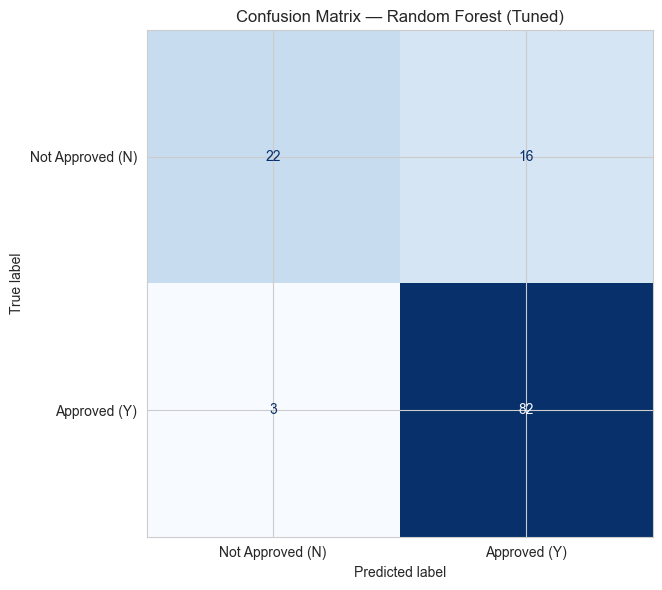

True Positives (TP):  82
True Negatives (TN):  22
False Positives (FP): 16
False Negatives (FN): 3


In [24]:
# --- Confusion Matrix ---
# Shows true positives, true negatives, false positives, false negatives
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Approved (N)', 'Approved (Y)'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest (Tuned)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (TP):  {tp}")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

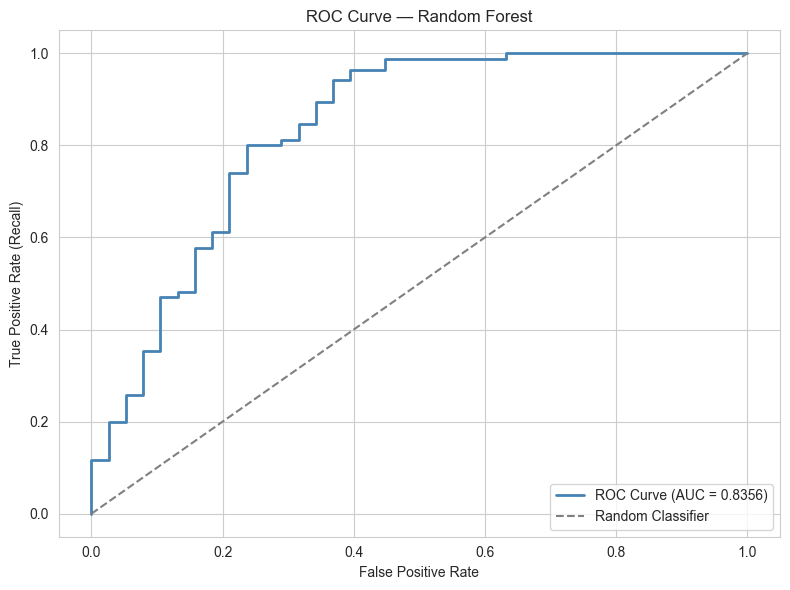

AUC Score: 0.8356


In [25]:
# --- ROC Curve and AUC Score ---
# AUC (Area Under Curve) measures model discrimination ability (1.0 = perfect)
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

10-Fold Cross-Validation Scores: [0.8065 0.8226 0.7419 0.7581 0.8033 0.7869 0.8361 0.8525 0.8033 0.8361]
Mean CV Accuracy: 80.47%
Standard Deviation: 3.32%


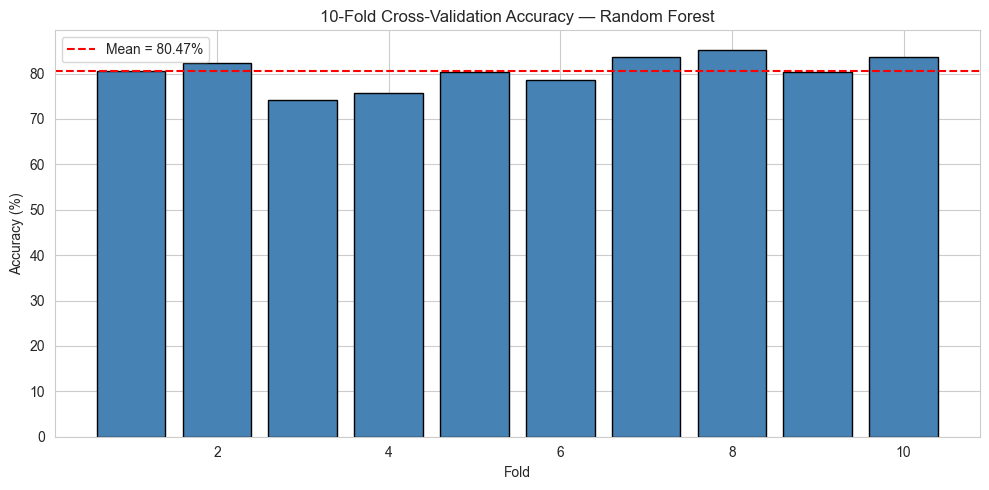

In [26]:
# --- Cross-Validation Score ---
# Provides a more reliable estimate of model performance across different data splits
cv_scores = cross_val_score(rf_tuned, X, y, cv=10, scoring='accuracy')

print(f"10-Fold Cross-Validation Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

# Visualize CV scores
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores * 100, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--', label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.title('10-Fold Cross-Validation Accuracy — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance

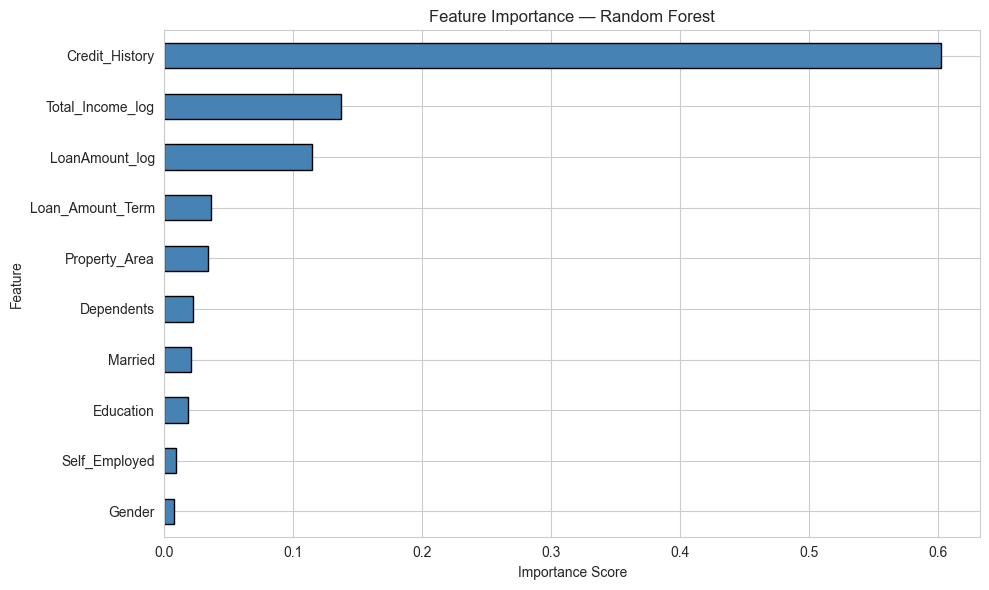

Feature Importance Scores (sorted):
Credit_History      0.6023
Total_Income_log    0.1368
LoanAmount_log      0.1147
Loan_Amount_Term    0.0361
Property_Area       0.0336
Dependents          0.0220
Married             0.0203
Education           0.0180
Self_Employed       0.0087
Gender              0.0074
dtype: float64


In [ ]:
# Random Forest provides feature importance scores
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature Importance Scores (sorted):")
print(importances.sort_values(ascending=False).round(4))

## 9. Results Summary

In [28]:
# Summary table comparing Baseline vs Tuned model
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_base = rf_baseline.predict(X_test)
y_pred_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

results = {
    'Model': ['Random Forest (Baseline)', 'Random Forest (Tuned)'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, y_pred_base) * 100, 2),
        round(accuracy_score(y_test, y_pred) * 100, 2)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_base), 4),
        round(precision_score(y_test, y_pred), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_base), 4),
        round(recall_score(y_test, y_pred), 4)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_base), 4),
        round(f1_score(y_test, y_pred), 4)
    ],
    'AUC Score': [
        round(roc_auc_score(y_test, y_pred_proba_base), 4),
        round(roc_auc_score(y_test, y_pred_proba), 4)
    ]
}

results_df = pd.DataFrame(results)
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

RESULTS SUMMARY
                   Model  Accuracy (%)  Precision  Recall  F1 Score  AUC Score
Random Forest (Baseline)         82.11     0.8462  0.9059    0.8750     0.8237
   Random Forest (Tuned)         84.55     0.8367  0.9647    0.8962     0.8356
